In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
matches = pd.read_csv('WorldCupMatches.csv')
players = pd.read_csv('WorldCupPlayers.csv')
cups = pd.read_csv('WorldCups.csv')

# 1 Workig with Historical matches

In [4]:
matches.dropna(inplace=True)
matches

,Year,Datetime,Stage,Stadium,City,Home Team Name,Home Team Goals,Away Team Goals,Away Team Name,Win conditions,Attendance,Half-time Home Goals,Half-time Away Goals,Referee,Assistant 1,Assistant 2,RoundID,MatchID,Home Team Initials,Away Team Initials
0,1930,13 Jul 1930 - 15:00,Group 1,Pocitos,Montevideo,France,4,1,Mexico,,4444.0,3,0,LOMBARDI Domingo (URU),CRISTOPHE Henry (BEL),REGO Gilberto (BRA),201,1096,FRA,MEX
1,1930,13 Jul 1930 - 15:00,Group 4,Parque Central,Montevideo,USA,3,0,Belgium,,18346.0,2,0,MACIAS Jose (ARG),MATEUCCI Francisco (URU),WARNKEN Alberto (CHI),201,1090,USA,BEL
2,1930,14 Jul 1930 - 12:45,Group 2,Parque Central,Montevideo,Yugoslavia,2,1,Brazil,,24059.0,2,0,TEJADA Anibal (URU),VALLARINO Ricardo (URU),BALWAY Thomas (FRA),201,1093,YUG,BRA
3,1930,14 Jul 1930 - 14:50,Group 3,Pocitos,Montevideo,Romania,3,1,Peru,,2549.0,1,0,WARNKEN Alberto (CHI),LANGENUS Jean (BEL),MATEUCCI Francisco (URU),201,1098,ROU,PER
4,1930,15 Jul 1930 - 16:00,Group 1,Parque Central,Montevideo,Argentina,1,0,France,,23409.0,0,0,REGO Gilberto (BRA),SAUCEDO Ulises (BOL),RADULESCU Constantin (ROU),201,1085,ARG,FRA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
847,2014,05 Jul 2014 - 17:00,Quarter-finals,Arena Fonte Nova,Salvador,Netherlands,0,0,Costa Rica,Netherlands win on penalties (4 - 3),51179.0,0,0,Ravshan IRMATOV (UZB),RASULOV Abduxamidullo (UZB),KOCHKAROV Bakhadyr (KGZ),255953,300186488,NED,CRC
848,2014,08 Jul 2014 - 17:00,Semi-finals,Estadio Mineirao,Belo Horizonte,Brazil,1,7,Germany,,58141.0,0,5,RODRIGUEZ Marco (MEX),TORRENTERA Marvin (MEX),QUINTERO Marcos (MEX),255955,300186474,BRA,GER
849,2014,09 Jul 2014 - 17:00,Semi-finals,Arena de Sao Paulo,Sao Paulo,Netherlands,0,0,Argentina,Argentina win on penalties (2 - 4),63267.0,0,0,C�neyt �AKIR (TUR),DURAN Bahattin (TUR),ONGUN Tarik (TUR),255955,300186490,NED,ARG
850,2014,12 Jul 2014 - 17:00,Play-off for third place,Estadio Nacional,Brasilia,Brazil,0,3,Netherlands,,68034.0,0,2,HAIMOUDI Djamel (ALG),ACHIK Redouane (MAR),ETCHIALI Abdelhak (ALG),255957,300186502,BRA,NED


In [5]:
matches.info()

<class 'pandas.DataFrame'>
Index: 850 entries, 0 to 851
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  850 non-null    int64  
 1   Datetime              850 non-null    str    
 2   Stage                 850 non-null    str    
 3   Stadium               850 non-null    str    
 4   City                  850 non-null    str    
 5   Home Team Name        850 non-null    str    
 6   Home Team Goals       850 non-null    int64  
 7   Away Team Goals       850 non-null    int64  
 8   Away Team Name        850 non-null    str    
 9   Win conditions        850 non-null    str    
 10  Attendance            850 non-null    float64
 11  Half-time Home Goals  850 non-null    int64  
 12  Half-time Away Goals  850 non-null    int64  
 13  Referee               850 non-null    str    
 14  Assistant 1           850 non-null    str    
 15  Assistant 2           850 non-null    s

In [6]:
sns.set_style('whitegrid')
plt.rc('figure', figsize=(12,6))

matches['date'] = pd.to_datetime(matches['Datetime'], format='mixed', dayfirst=True, errors='coerce')
matches['year'] = matches['date'].dt.year

matches['total_goals'] = matches['Home Team Goals'] + matches['Away Team Goals']

def get_results(h, a):
    if h > a:
        return 'Home Win'
    elif h < a:
        return 'Away Win'
    else:
        return 'Draw'

matches['result'] = matches.apply(lambda row: get_results(row['Home Team Goals'], row['Away Team Goals']), axis=1)

print(f'Total matches played {len(matches)}')

Total matches played 850


# i) Goals Distributions

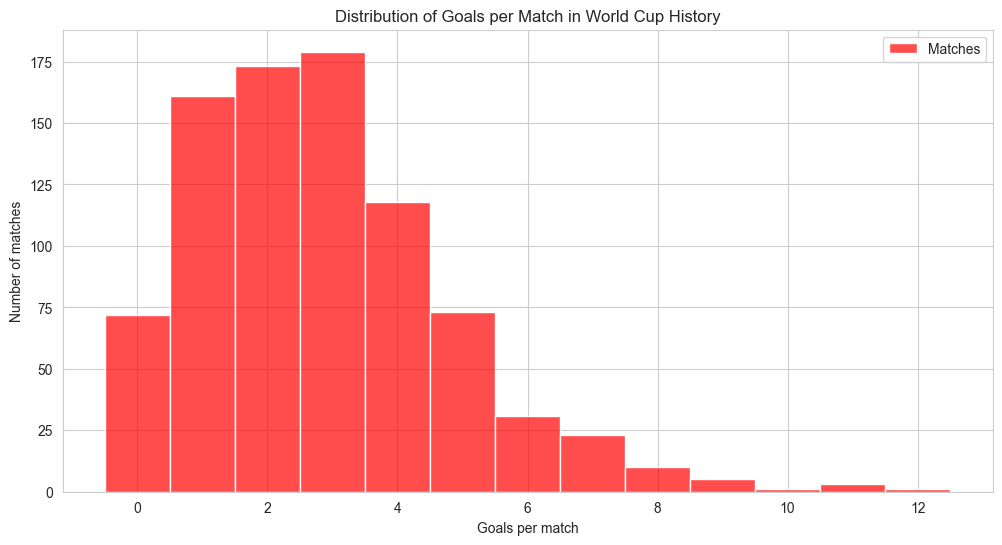

In [7]:
# Goal distribution
plt.figure()
sns.histplot(data=matches, x='total_goals', discrete=True, color='red', alpha=0.7, label='Matches')
plt.xlabel('Goals per match')
plt.ylabel('Number of matches')
plt.title('Distribution of Goals per Match in World Cup History')
plt.legend()
plt.show()

>> The observed insight here is that most matches have total goals of 2 $ 3

# ii) Results Breakdown

(np.float64(-1.0999984156490017),
 np.float64(1.0999881018168356),
 np.float64(-1.0999996518494413),
 np.float64(1.0999928624453101))

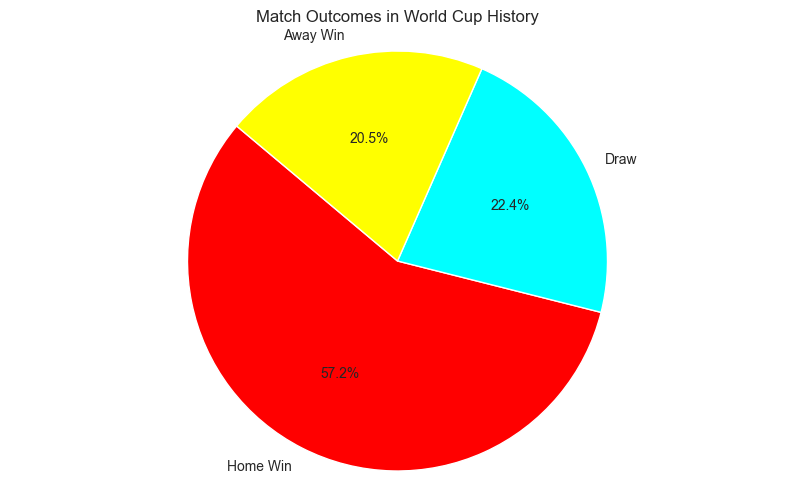

In [8]:
plt.figure(figsize=(10,6))
colors = ['red', 'aqua', 'yellow']

matches['result'].value_counts(normalize=True).plot.pie(autopct='%.1f%%', colors=colors, startangle=140)
plt.title('Match Outcomes in World Cup History')
plt.axis('equal')

>> The insight: Home advantage is huge 

# iii) Goal trends over the years

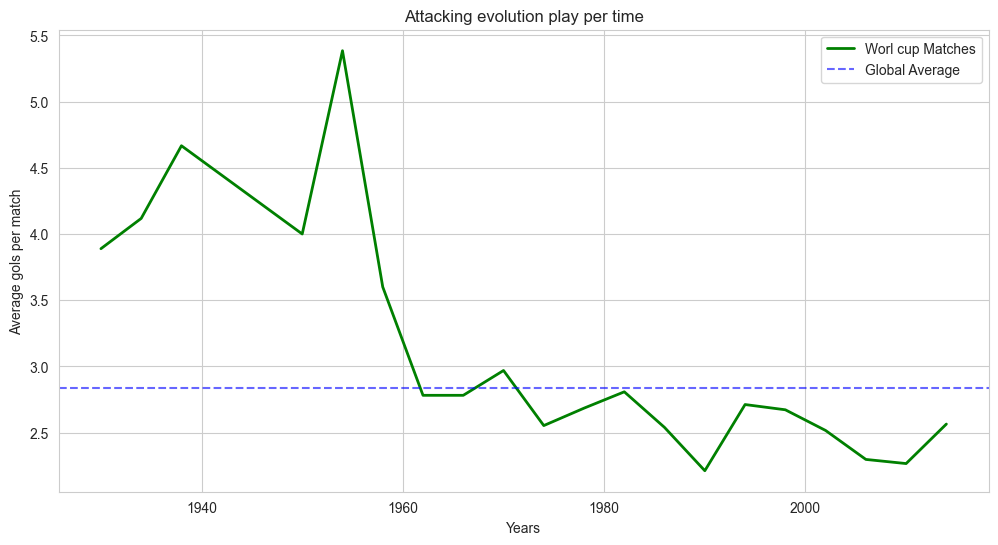

In [9]:
avg_goals_year = matches.groupby('year')['total_goals'].mean()

plt.figure()
sns.lineplot(x=avg_goals_year.index, y=avg_goals_year.values, label = 'Worl cup Matches', color = 'green', linewidth=2)
plt.axhline(y=matches['total_goals'].mean(), linestyle = '--', color = 'blue', alpha = 0.6, label = 'Global Average')
plt.xlabel('Years')
plt.ylabel('Average gols per match')
plt.title('Attacking evolution play per time')
plt.legend()
plt.show()

# iv) Top perfomance teams

C:\Users\HomePC\AppData\Local\Temp\ipykernel_7012\3937838663.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.values, y=top10.index, palette='Reds_r')


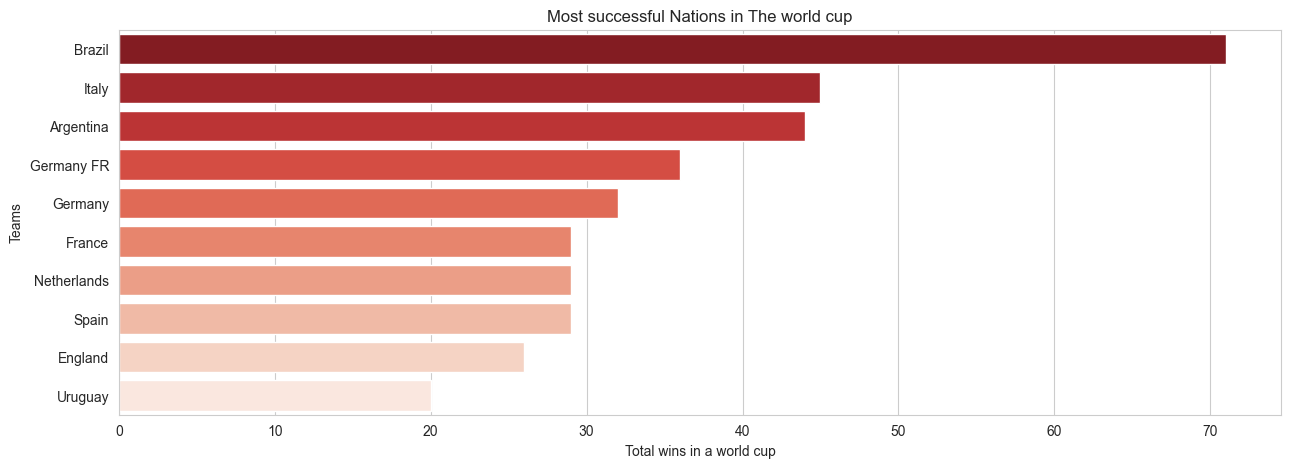

In [10]:
def get_wins(team):
    home = matches[(matches['Home Team Name'] == team) & (matches['Home Team Goals'] > matches['Away Team Goals'])].shape[0]
    away = matches[(matches['Away Team Name'] == team) & (matches['Away Team Goals'] > matches['Home Team Goals'])].shape[0]
    return home + away

top_teams = matches['Home Team Name'].unique()
records = {team:get_wins(team) for team in top_teams}
top10 = pd.Series(records).sort_values(ascending=False).head(10)

plt.figure(figsize=(15,5))
sns.barplot(x=top10.values, y=top10.index, palette='Reds_r')
plt.xlabel('Total wins in a world cup')
plt.ylabel('Teams')
plt.title('Most successful Nations in The world cup')
plt.show()

>> The insight: Brazil is the leading successful team in the world cup

---

In [11]:
wc = pd.read_csv('FIFA World Cup 1930-2022 All Match Dataset.csv', encoding='latin-1')
wc.info()

<class 'pandas.DataFrame'>
RangeIndex: 964 entries, 0 to 963
Data columns (total 37 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Key Id                     964 non-null    int64
 1   Tournament Id              964 non-null    str  
 2   tournament Name            964 non-null    str  
 3   Match Id                   964 non-null    str  
 4   Match Name                 964 non-null    str  
 5   Stage Name                 964 non-null    str  
 6   Group Name                 964 non-null    str  
 7   Group Stage                964 non-null    int64
 8   Knockout Stage             964 non-null    int64
 9   Replayed                   964 non-null    int64
 10  Replay                     964 non-null    int64
 11  Match Date                 964 non-null    str  
 12  Match Time                 964 non-null    str  
 13  Stadium Id                 964 non-null    str  
 14  Stadium Name               964 non-nu

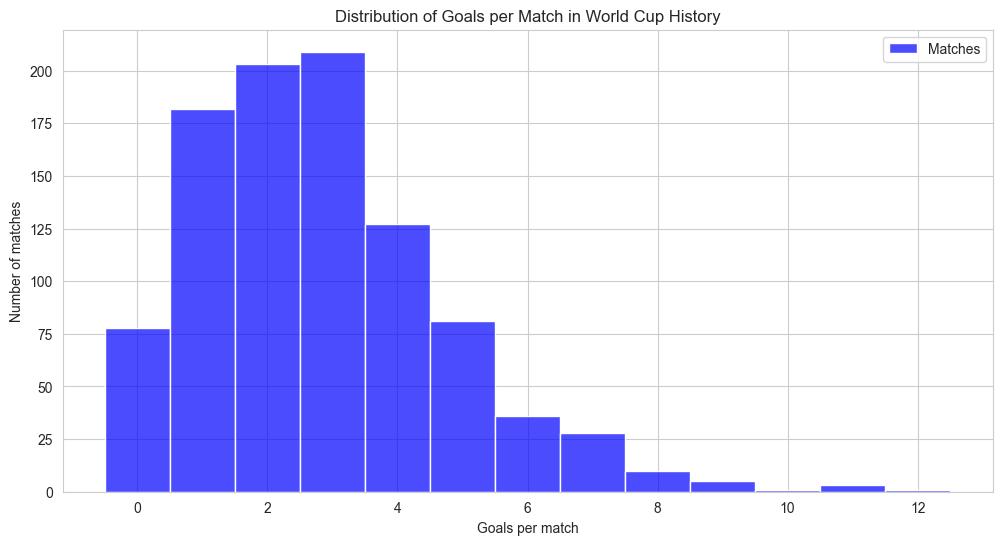

In [12]:
wc['date'] = pd.to_datetime(wc['Match Date'], errors='coerce', format='mixed', dayfirst=True)
wc['year'] = wc['date'].dt.year
wc['Total_goals'] = wc['Home Team Score'] + wc['Away Team Score']

plt.figure()
sns.histplot(data=wc, x='Total_goals', discrete=True, color='blue', alpha=0.7, label='Matches')
plt.xlabel('Goals per match')
plt.ylabel('Number of matches')
plt.title('Distribution of Goals per Match in World Cup History')
plt.legend()
plt.show()

(np.float64(-1.0999979317972775),
 np.float64(1.0999759997767007),
 np.float64(-1.0999996957023486),
 np.float64(1.0999948407083624))

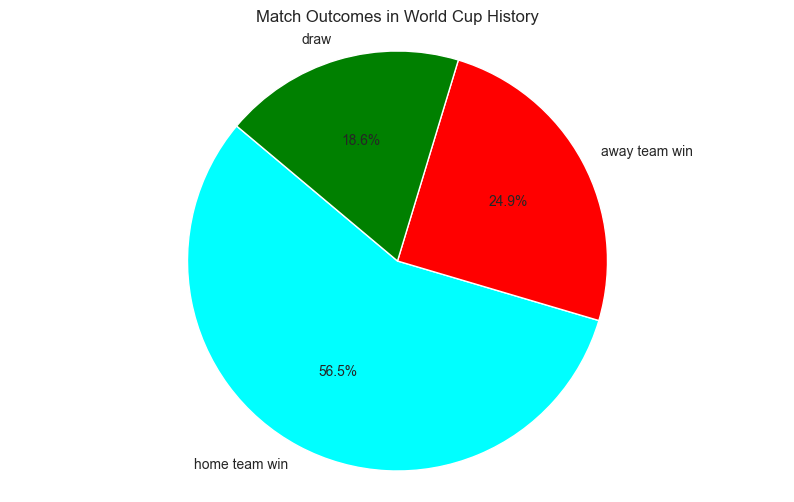

In [13]:
plt.figure(figsize=(10,6))
colors = ['aqua', 'red', 'green']

wc['Result'].value_counts(normalize=True).plot.pie(autopct='%.1f%%', colors=colors, startangle=140)
plt.title('Match Outcomes in World Cup History')
plt.axis('equal')

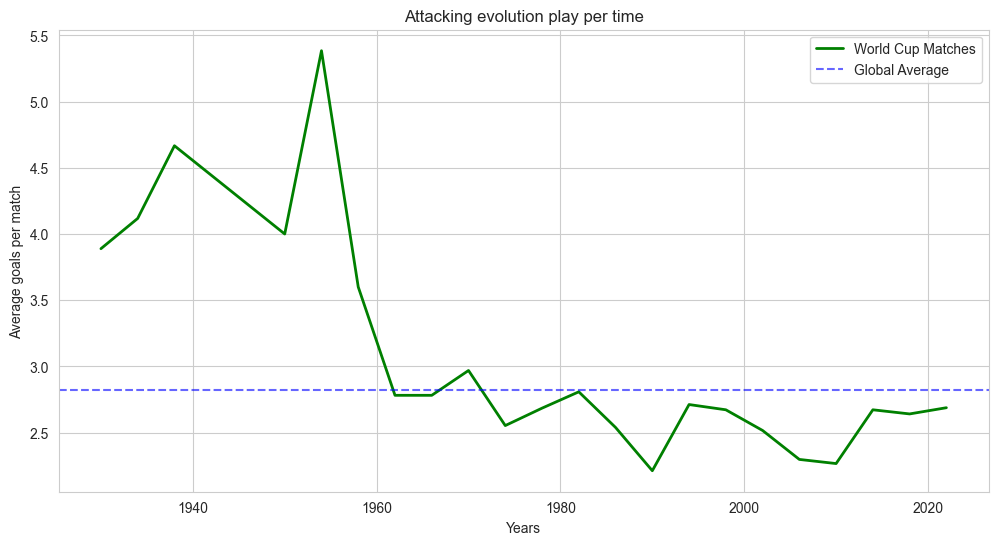

In [14]:
avg_goals_year = wc.groupby('year')['Total_goals'].mean()

plt.figure()
sns.lineplot(x=avg_goals_year.index, y=avg_goals_year.values, label = 'World Cup Matches', color = 'green', linewidth=2)
plt.axhline(y=wc['Total_goals'].mean(), linestyle = '--', color = 'blue', alpha = 0.6, label = 'Global Average')
plt.xlabel('Years')
plt.ylabel('Average goals per match')
plt.title('Attacking evolution play per time')
plt.legend()
plt.show()

C:\Users\HomePC\AppData\Local\Temp\ipykernel_7012\3224824102.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.values, y=top10.index, palette='Reds_r')


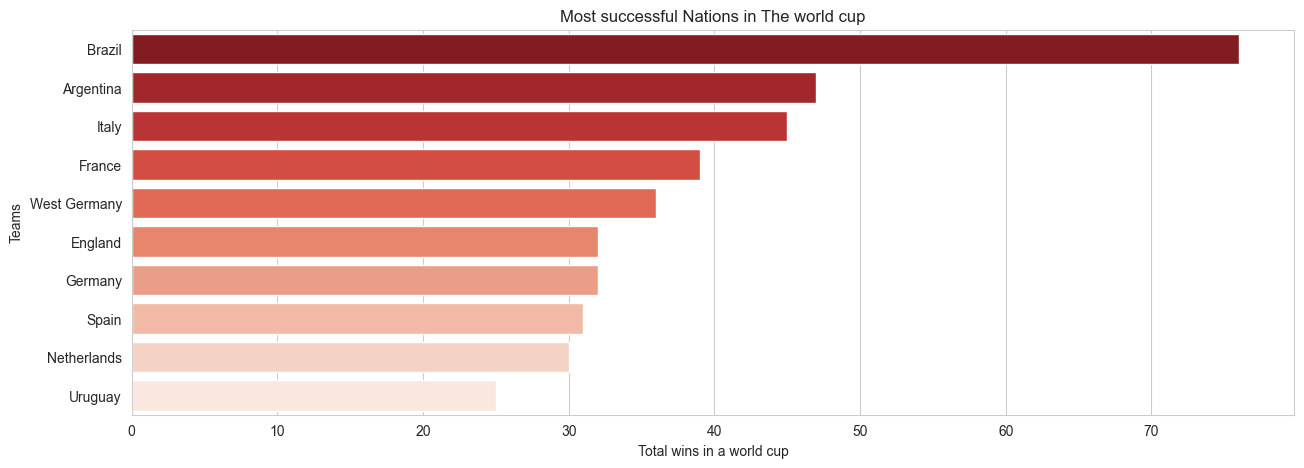

In [15]:
def get_wins(team):
    home = wc[(wc['Home Team Name'] == team) & (wc['Home Team Score'] > wc['Away Team Score'])].shape[0]
    away = wc[(wc['Away Team Name'] == team) & (wc['Away Team Score'] > wc['Home Team Score'])].shape[0]
    return home + away

top_teams = wc['Home Team Name'].unique()
records = {team:get_wins(team) for team in top_teams}
top10 = pd.Series(records).sort_values(ascending=False).head(10)

plt.figure(figsize=(15,5))
sns.barplot(x=top10.values, y=top10.index, palette='Reds_r')
plt.xlabel('Total wins in a world cup')
plt.ylabel('Teams')
plt.title('Most successful Nations in The world cup')
plt.show()